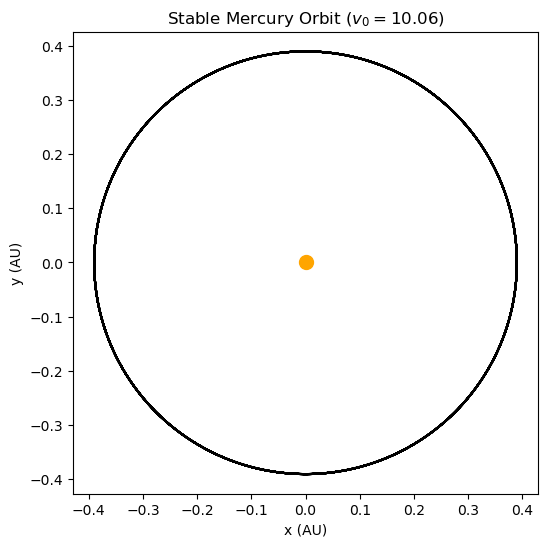

In [58]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("mercuryOrbit.txt")
x = data[:, 1]  # Extract x positions
y = data[:, 2]  # Extract y positions

#Plotting
plt.figure(figsize=(6,6))
plt.plot(x, y, color="black", label="Mercury's Orbit") 
plt.scatter(0, 0, color="orange", s=100, label="Sun")
plt.ylabel("y (AU)")
plt.xlabel("x (AU)")
plt.title("Stable Mercury Orbit ($v_0 = 10.06$)")
plt.axis("equal") 
plt.show()


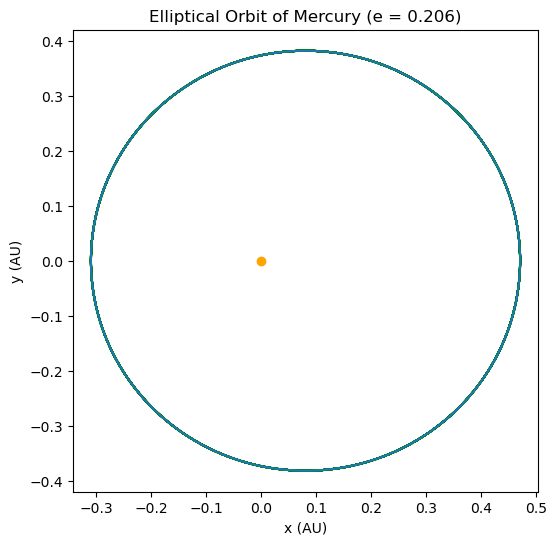

In [80]:
import numpy as np
import matplotlib.pyplot as plt

# Load the numerical results from the C++ simulation
data = np.loadtxt("mercury_ellipse.txt")
t = data[:,0]
x_num = data[:,1]
y_num = data[:,2]

# **Plot Numerical Orbit**
plt.figure(figsize=(6,6))
plt.plot(x_num, y_num, color="green", label="Numerical Orbit")

# **Plot the Sun at the Focus**
plt.plot(0, 0, 'o', color='orange', label="Sun")

# **Analytical Ellipse Calculation**
a = 0.39
e = 0.206
theta = np.linspace(0, 2*np.pi, 300)
r = a*(1 - e**2)/(1 + e*np.cos(theta))

# Shift the ellipse by π so aphelion is at +x:
x_analytic = r * np.cos(theta + np.pi)
y_analytic = r * np.sin(theta + np.pi)


# **Plot Analytical Ellipse (Dashed Black Line)**
plt.plot(x_analytic, y_analytic, label="Analytic Ellipse")

# **Final Plot Settings**
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.title("Elliptical Orbit of Mercury (e = 0.206)")
plt.axis("equal")
plt.show()


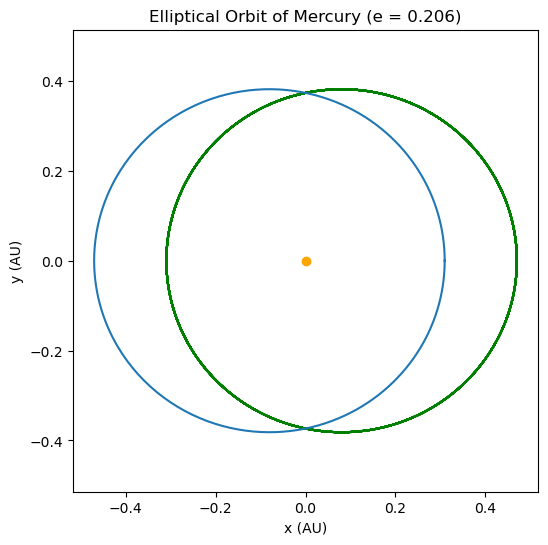

In [78]:
import numpy as np
import matplotlib.pyplot as plt

# Load the numerical results from the C++ simulation
data = np.loadtxt("mercury_ellipse.txt")
t = data[:,0]
x_num = data[:,1]
y_num = data[:,2]

# **Plot Numerical Orbit**
plt.figure(figsize=(6,6))
plt.plot(x_num, y_num, color="green", label="Numerical Orbit")

# **Plot the Sun at the Focus**
plt.plot(0, 0, 'o', color='orange', label="Sun")

# **Analytical Ellipse Calculation**
a = 0.39
e = 0.206
theta = np.linspace(0, 2*np.pi, 300)
r = a*(1 - e**2) / (1 + e*np.cos(theta))
x_analytic = r*np.cos(theta)
y_analytic = r*np.sin(theta)

# **Plot Analytical Ellipse (Dashed Black Line)**
plt.plot(x_analytic, y_analytic, label="Analytic Ellipse")

# **Final Plot Settings**
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.title("Elliptical Orbit of Mercury (e = 0.206)")
plt.axis("equal")
plt.show()


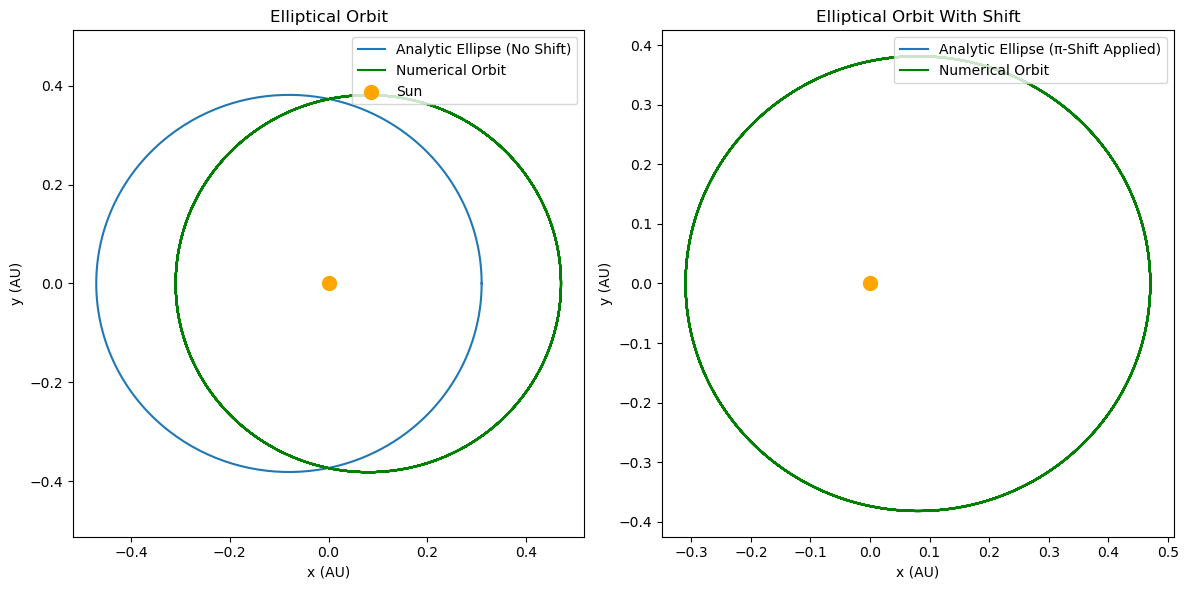

In [104]:
import numpy as np
import matplotlib.pyplot as plt

# Define Mercury's orbital parameters
a = 0.39   # Semi-major axis in AU
e = 0.206  # Eccentricity

# Load the numerical simulation data
data = np.loadtxt("mercuryOrbitEllipse.txt")
x_num = data[:, 1]  # Extract x positions from numerical simulation
y_num = data[:, 2]  # Extract y positions from numerical simulation

# Generate a range of θ values (0 to 2π)
theta = np.linspace(0, 2*np.pi, 300)

# Compute r(θ) from the ellipse equation
r = a * (1 - e**2) / (1 + e * np.cos(theta))

# Convert polar (r, θ) to Cartesian (WITHOUT correction)
x_analytic_no_shift = r * np.cos(theta)
y_analytic_no_shift = r * np.sin(theta)

# Convert polar (r, θ) to Cartesian (WITH π correction)
x_analytic_shifted = r * np.cos(theta + np.pi)
y_analytic_shifted = r * np.sin(theta + np.pi)

# Create side-by-side comparison plots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# **Left Plot: Without Correction (Mirrored Effect)**
axes[0].plot(x_analytic_no_shift, y_analytic_no_shift, label="Analytic Ellipse (No Shift)")
axes[0].plot(x_num, y_num, color="green", label="Numerical Orbit")
axes[0].scatter(0, 0, color="orange", s=100, label="Sun")
axes[0].set_xlabel("x (AU)")
axes[0].set_ylabel("y (AU)")
axes[0].set_title("Elliptical Orbit")
axes[0].axis("equal")
axes[0].legend(loc="upper right")

# **Right Plot: With Correction (Aligned)**
axes[1].plot(x_analytic_shifted, y_analytic_shifted, label="Analytic Ellipse (π-Shift Applied)")
axes[1].plot(x_num, y_num, color="green", label="Numerical Orbit")
axes[1].scatter(0, 0, color="orange", s=100) 
axes[1].set_xlabel("x (AU)")
axes[1].set_ylabel("y (AU)")
axes[1].set_title("Elliptical Orbit With Shift")
axes[1].axis("equal")
plt.legend(loc="upper right")

# Show the plots
plt.tight_layout()
plt.show()


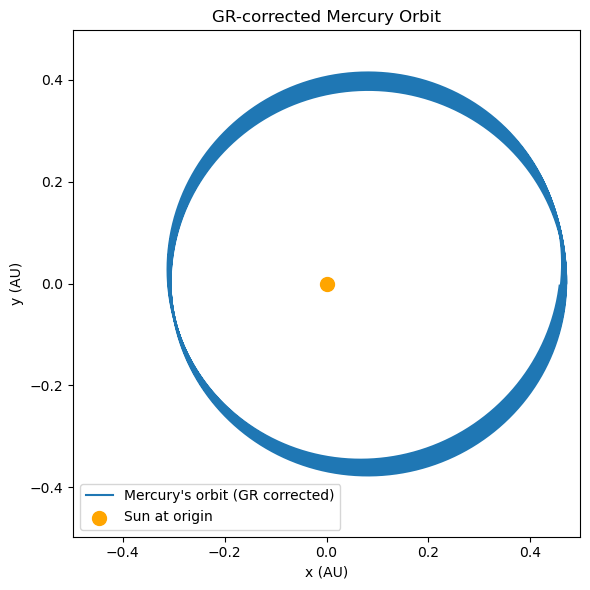

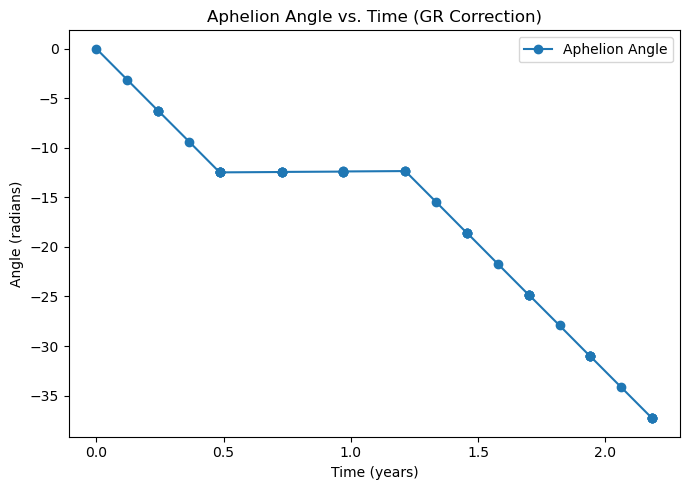

In [110]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Load the GR-corrected simulation data
#    File format: t, x, y, vx, vy
data = np.loadtxt("mercury_gr.txt")
t = data[:, 0]
x = data[:, 1]
y = data[:, 2]

# 2) Compute distance r(t) and angle theta(t)
r = np.sqrt(x**2 + y**2)
theta = np.arctan2(y, x)  # range: -pi to pi

# 3) Find local maxima of r(t) to identify aphelion points
#    A simple criterion: r[i] > r[i-1] and r[i] > r[i+1]
aphelion_times = []
aphelion_angles = []

for i in range(1, len(r) - 1):
    if r[i] > r[i - 1] and r[i] > r[i + 1]:
        aphelion_times.append(t[i])
        aphelion_angles.append(theta[i])

# 4) "Unwrap" angles so they don't jump from +pi to -pi
aphelion_angles = np.unwrap(aphelion_angles)

# --------------------------------------
# Part A: Plot the orbit in the xy-plane
# --------------------------------------
plt.figure(figsize=(6,6))
plt.plot(x, y, label="Mercury's orbit (GR corrected)")
plt.scatter(0, 0, color="orange", s=100, label="Sun at origin")
plt.axis("equal")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.title("GR-corrected Mercury Orbit")
plt.legend()
plt.xlim(-0.5, 0.5)
plt.ylim(-0.5, 0.5)
plt.tight_layout()
plt.show()

# ------------------------------------------
# Part B: Plot aphelion angle vs. time
# ------------------------------------------
plt.figure(figsize=(7,5))
plt.plot(aphelion_times, aphelion_angles, 'o-', label="Aphelion Angle")
plt.xlabel("Time (years)")
plt.ylabel("Angle (radians)")
plt.title("Aphelion Angle vs. Time (GR Correction)")
plt.legend()
plt.tight_layout()
plt.show()


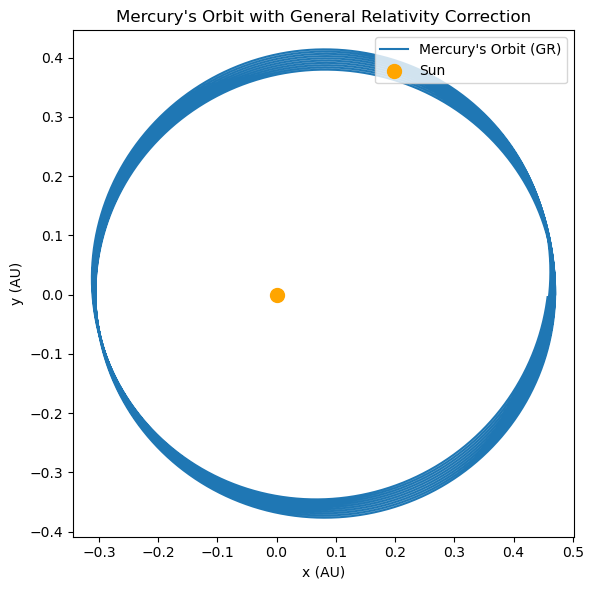

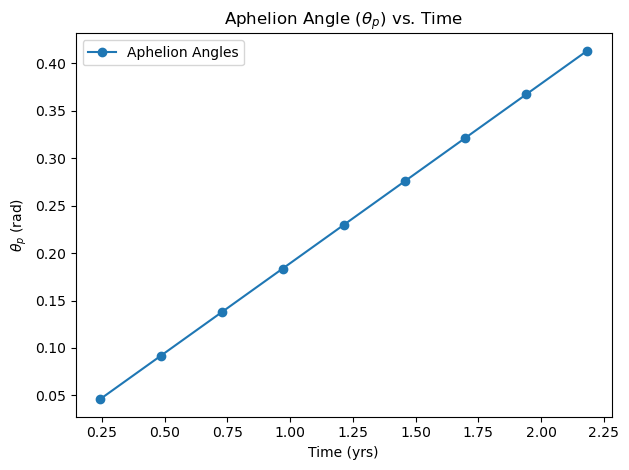

In [271]:
import numpy as np
import matplotlib.pyplot as plt

def radial_velocity(x, y, vx, vy):
    """Compute the radial velocity component v_r = (r · v) / |r|."""
    r = np.sqrt(x*x + y*y)
    # Avoid dividing by zero if r ~ 0
    if r < 1e-15:
        return 0.0
    return (x*vx + y*vy) / r

# -------------------------------------------
# 1) Load data from your GR-corrected orbit
#    Format: t, x, y, vx, vy
# -------------------------------------------
data = np.loadtxt("mercury_gr.txt")
t  = data[:,0]
x  = data[:,1]
y  = data[:,2]
vx = data[:,3]
vy = data[:,4]

# Compute r(t) and theta(t) if you want them
r     = np.sqrt(x**2 + y**2)
theta = np.arctan2(y, x)        # angle in [-pi, pi]

# -------------------------------------------
# 2) Compute radial velocity for each time
# -------------------------------------------
vr = np.array([radial_velocity(x[i], y[i], vx[i], vy[i]) 
               for i in range(len(t))])

# -------------------------------------------
# 3) Detect perihelia and aphelia
#    We'll track them in arrays:
#    perihelion_times, perihelion_angles
#    aphelion_times, aphelion_angles
# -------------------------------------------
perihelion_times  = []
perihelion_angles = []
aphelion_times    = []
aphelion_angles   = []

# Start by looking for the FIRST perihelion
looking_for_perihelion = True

for i in range(1, len(t)):
    # Check the sign of radial velocity
    sign_prev = np.sign(vr[i-1])
    sign_now  = np.sign(vr[i])

    # 3A) Perihelion detection: negative -> positive
    if looking_for_perihelion:
        if sign_prev < 0 and sign_now >= 0:
            # We found a perihelion crossing
            perihelion_times.append(t[i])
            perihelion_angles.append(theta[i])
            looking_for_perihelion = False

    # 3B) Aphelion detection: positive -> negative
    else:
        if sign_prev > 0 and sign_now <= 0:
            # We found an aphelion crossing
            aphelion_times.append(t[i])
            aphelion_angles.append(theta[i])
            looking_for_perihelion = True

# -------------------------------------------
# 4) "Unwrap" angles so they don't jump 
#    from +π to -π
# -------------------------------------------
perihelion_angles = np.unwrap(perihelion_angles)
aphelion_angles   = np.unwrap(aphelion_angles)

# -------------------------------------------
# 5) Plot the orbit in xy-plane
# -------------------------------------------
plt.figure(figsize=(6,6))
plt.plot(x, y, label="Mercury's Orbit (GR)")
plt.scatter(0, 0, color='orange', s=100, label="Sun")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.title("Mercury's Orbit with General Relativity Correction")
plt.axis("equal")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# -------------------------------------------
# 6) Plot the aphelion angle vs. time
# -------------------------------------------
plt.figure()
plt.plot(aphelion_times, aphelion_angles, 'o-', label="Aphelion Angles")
plt.xlabel("Time (yrs)")
plt.ylabel(r'$\theta_p$ (rad)')
plt.title(r"Aphelion Angle ($\theta_p$) vs. Time")
plt.legend()
plt.tight_layout()
plt.show()


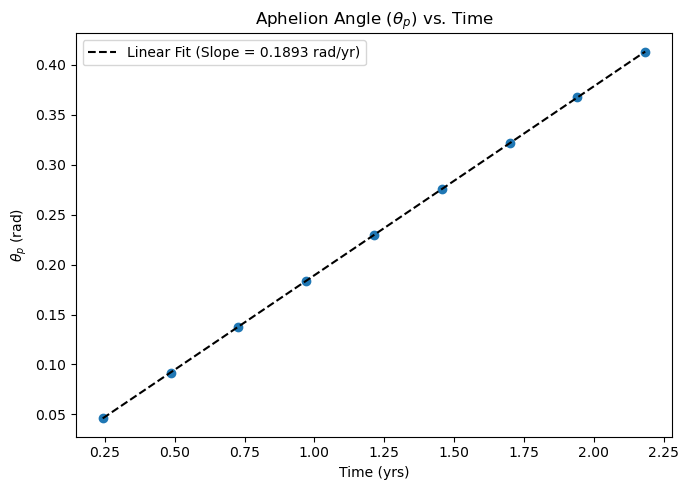

Estimated Precession Rate (Linear Fit): 0.1893 rad/year


In [275]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Load the aphelion data from the previous detection
# Assuming we have already extracted the aphelion_times and aphelion_angles
data = np.loadtxt("mercury_gr.txt")
t  = data[:,0]
x  = data[:,1]
y  = data[:,2]
vx = data[:,3]
vy = data[:,4]

# Recompute radial velocity
vr = (x * vx + y * vy) / np.sqrt(x**2 + y**2)

# Recompute aphelion times & angles using radial velocity sign change
aphelion_times = []
aphelion_angles = []
looking_for_aphelion = False  # Start by looking for a perihelion first

for i in range(1, len(t)):
    if looking_for_aphelion:
        if vr[i - 1] > 0 and vr[i] <= 0:
            aphelion_times.append(t[i])
            aphelion_angles.append(np.arctan2(y[i], x[i]))
            looking_for_aphelion = False  # Switch to looking for perihelion
    else:
        if vr[i - 1] < 0 and vr[i] >= 0:
            looking_for_aphelion = True  # Switch to looking for aphelion

# Convert to NumPy arrays for fitting
aphelion_times = np.array(aphelion_times)
aphelion_angles = np.unwrap(np.array(aphelion_angles))  # Prevent jumps at ±π

# Perform a linear fit to extract the slope
slope, intercept, r_value, p_value, std_err = linregress(aphelion_times, aphelion_angles)

# ---------------------------------------
# Plot the aphelion angle vs. time
# ---------------------------------------
plt.figure(figsize=(7,5))
plt.plot(aphelion_times, aphelion_angles, 'o')
plt.plot(aphelion_times, slope * aphelion_times + intercept, 'k--', label=f"Linear Fit (Slope = {slope:.4f} rad/yr)")
plt.xlabel("Time (yrs)")
plt.legend()
plt.ylabel(r'$\theta_p$ (rad)')
plt.title(r"Aphelion Angle ($\theta_p$) vs. Time")
plt.tight_layout()
plt.show()

# Print the precession rate
print(f"Estimated Precession Rate (Linear Fit): {slope:.4f} rad/year")


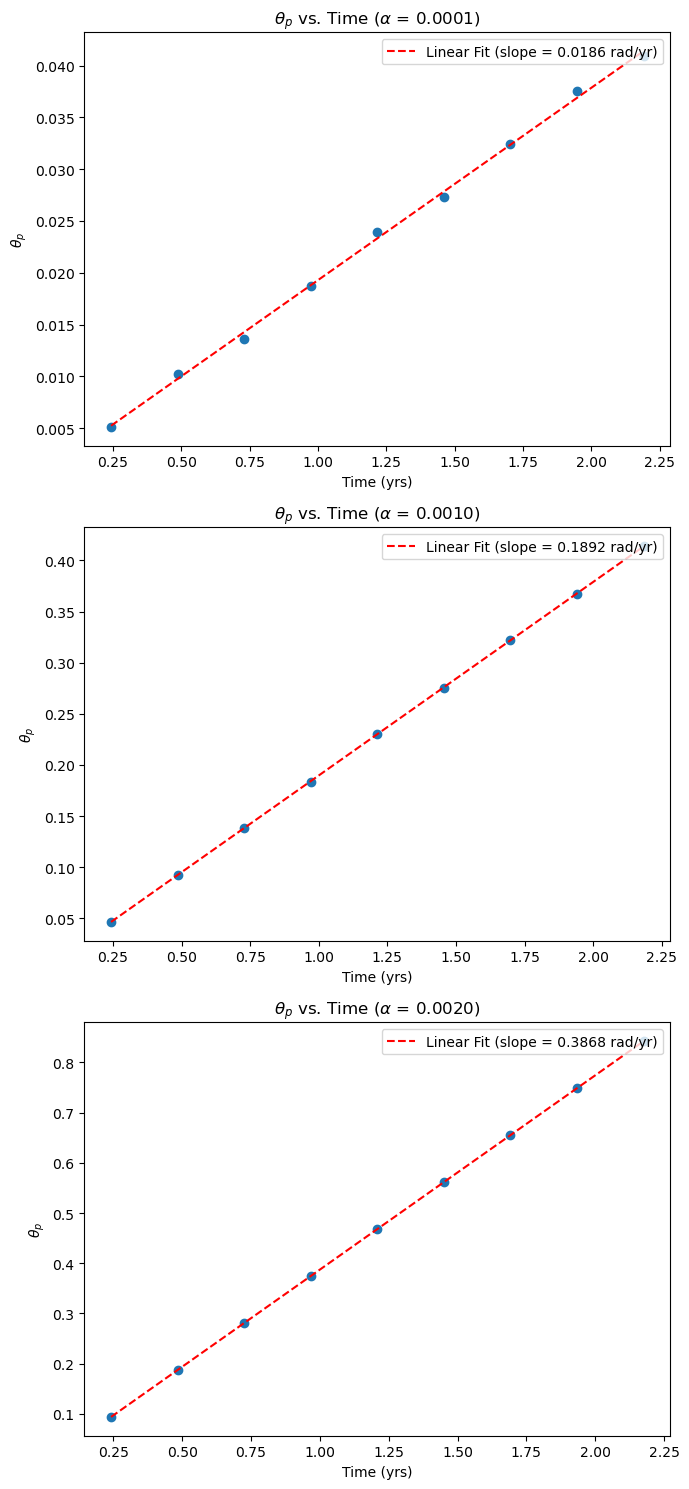

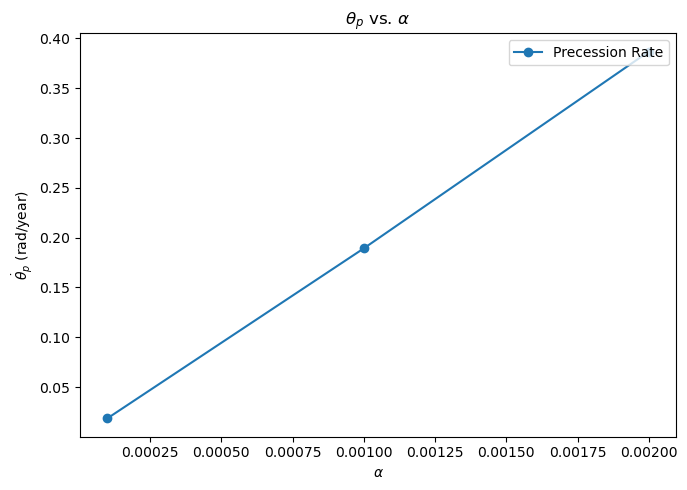

alpha = 0.0001 : Precession rate = 0.018563 rad/year
alpha = 0.0010 : Precession rate = 0.189246 rad/year
alpha = 0.0020 : Precession rate = 0.386813 rad/year
Precession rate at alpha=1.1e-8 is ~ 43.99075818369716 arcsec/century


In [315]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def radial_velocity(x, y, vx, vy):
    r = np.sqrt(x**2 + y**2)
    return (x * vx + y * vy) / r if r > 1e-15 else 0.0

def analyze_file(filename):
    data = np.loadtxt(filename)
    t  = data[:, 0]
    x  = data[:, 1]
    y  = data[:, 2]
    vx = data[:, 3]
    vy = data[:, 4]

    # Compute radial velocities for all time steps
    vr = np.array([radial_velocity(x[i], y[i], vx[i], vy[i]) for i in range(len(t))])
    
    # Detect aphelion points using the sign change of radial velocity:
    # Aphelion occurs when vr changes from positive to negative.
    aphelion_times = []
    aphelion_angles = []
    looking_for_aphelion = False  # start by waiting for a perihelion (vr from negative to positive)
    
    for i in range(1, len(t)):
        if looking_for_aphelion:
            if vr[i-1] > 0 and vr[i] <= 0:
                aphelion_times.append(t[i])
                aphelion_angles.append(np.arctan2(y[i], x[i]))
                looking_for_aphelion = False  # switch to looking for perihelion next
        else:
            if vr[i-1] < 0 and vr[i] >= 0:
                looking_for_aphelion = True  # now, next positive-to-negative will be an aphelion

    aphelion_times = np.array(aphelion_times)
    aphelion_angles = np.unwrap(np.array(aphelion_angles))  # Unwrap angles to avoid 2pi jumps

    # Linear regression to find precession rate (slope in rad/year)
    slope, intercept, r_value, p_value, std_err = linregress(aphelion_times, aphelion_angles)
    
    return t, x, y, aphelion_times, aphelion_angles, slope, intercept

# List of alpha values to test
alpha_list = [0.0001, 0.001, 0.002]
# Generate filenames using fixed 4-decimal formatting
filenames = ["mercury_gr_0.000100.txt", "mercury_gr_0.001000.txt", "mercury_gr_0.002000.txt"]

# Prepare lists to store precession rates
precession_rates = []

# Create a figure with subplots for aphelion angle vs. time for each alpha
fig_angles, axs = plt.subplots(len(alpha_list), 1, figsize=(7, 5*len(alpha_list)))
if len(alpha_list) == 1:
    axs = [axs]  # Ensure axs is iterable even if one alpha

# Loop over each alpha and corresponding file
for i, (alpha, fname) in enumerate(zip(alpha_list, filenames)):
        t, x, y, aph_times, aph_angles, slope, intercept = analyze_file(fname)
        precession_rates.append(slope)
        
        # Plot the aphelion angle vs. time with linear fit in its subplot
        axs[i].plot(aph_times, aph_angles, 'o')
        axs[i].plot(aph_times, slope * aph_times + intercept, 'r--',
                    label=f"Linear Fit (slope = {slope:.4f} rad/yr)")
        axs[i].set_xlabel("Time (yrs)")
        axs[i].set_ylabel(r'$\theta_p$')
        axs[i].set_title(r'$\theta_p $ vs. Time ($\alpha$' + f" = {alpha:.4f})")
        axs[i].legend(loc="upper right")

fig_angles.tight_layout()

# Plot precession rate vs. alpha
fig_rate, ax_rate = plt.subplots(figsize=(7,5))
ax_rate.plot(alpha_list, precession_rates, 'o-', label="Precession Rate")
ax_rate.set_xlabel(r'$\alpha$')
ax_rate.set_ylabel(r"$\dot{\theta}_p$ (rad/year)")
ax_rate.set_title(r'$\theta_p$ vs. $\alpha$')
ax_rate.legend(loc="upper right")
fig_rate.tight_layout()

plt.show()

# Print precession rates for each alpha
for alpha, rate in zip(alpha_list, precession_rates):
    print(f"alpha = {alpha:.4f} : Precession rate = {rate:.6f} rad/year")


# Convert precession rates to degrees/year
precession_rates_deg = np.array(precession_rates) * (180 / np.pi)

# Fit a linear model for precession rate vs. alpha
slope_deg_per_alpha, intercept, _, _, _ = linregress(alpha_list, precession_rates_deg)

dotTheta_deg_per_year = slope_deg_per_alpha * 1.1e-8
dotTheta_arcsec_per_century = dotTheta_deg_per_year * 3600 * 100

print("Precession rate at alpha=1.1e-8 is ~", dotTheta_arcsec_per_century, "arcsec/century")


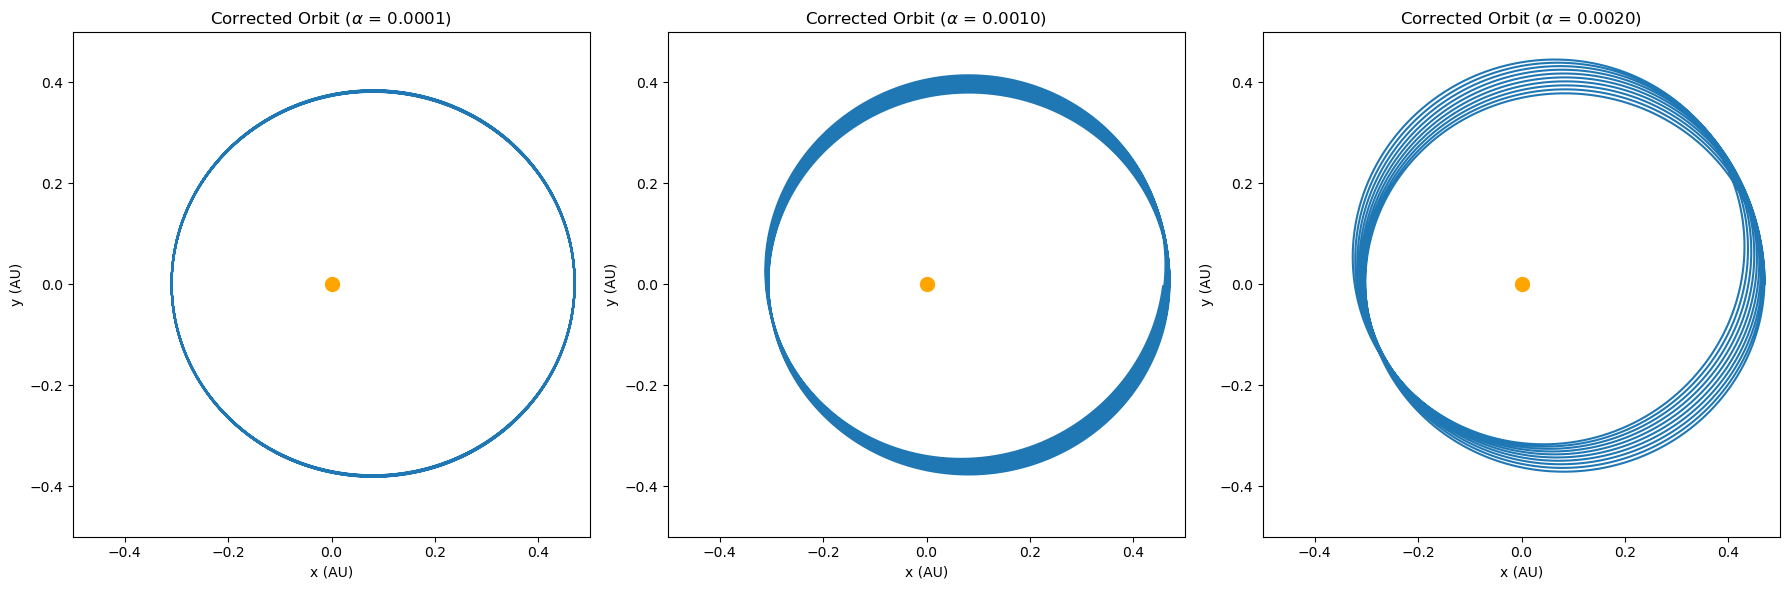

In [287]:
import numpy as np
import matplotlib.pyplot as plt

# Define the list of alpha values we used and corresponding filenames
alpha_list = [0.0001, 0.001, 0.002]
filenames = ["mercury_gr_0.000100.txt", "mercury_gr_0.001000.txt", "mercury_gr_0.002000.txt"]

# Create a figure with 1 row and 3 columns of subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (alpha, fname) in enumerate(zip(alpha_list, filenames)):
    # Load simulation data: assumed columns: t, x, y, vx, vy
    data = np.loadtxt(fname)
    x = data[:, 1]
    y = data[:, 2]

    # Plot the orbit in the corresponding subplot
    ax = axes[i]
    ax.plot(x, y, label=f"alpha = {alpha:.4f}")
    ax.scatter(0, 0, color="orange", s=100, label="Sun")  # Plot the Sun at the origin
    ax.set_xlabel("x (AU)")
    ax.set_ylabel("y (AU)")
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(-0.5, 0.5)
    ax.set_title(r"Corrected Orbit ($\alpha$" + f" = {alpha:.4f})")


plt.tight_layout()
plt.show()


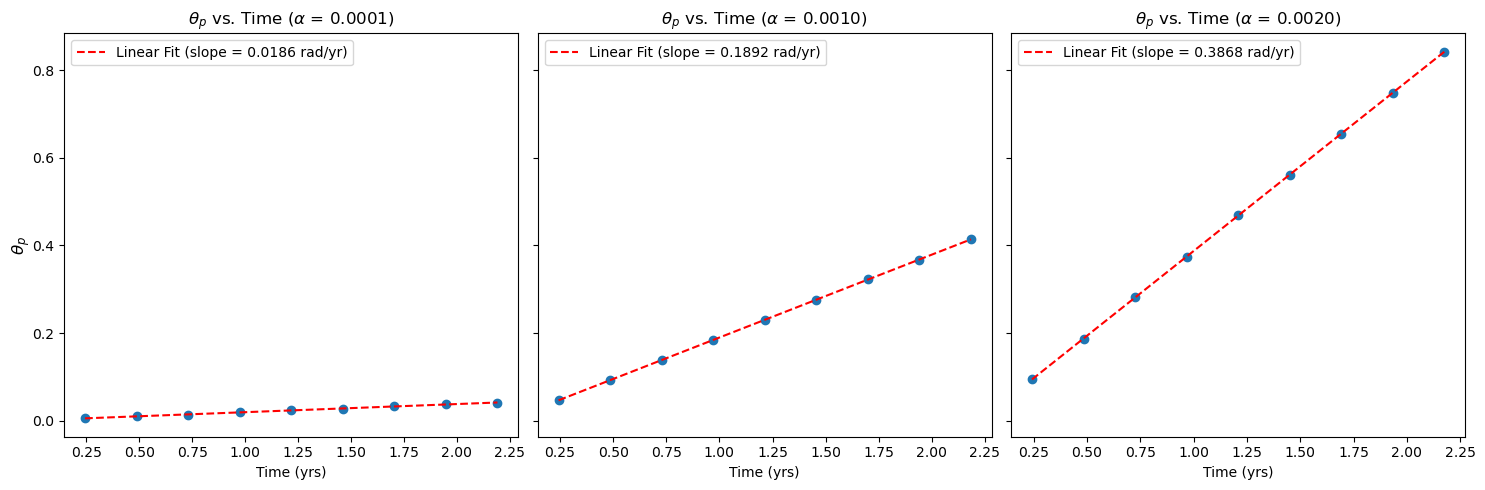

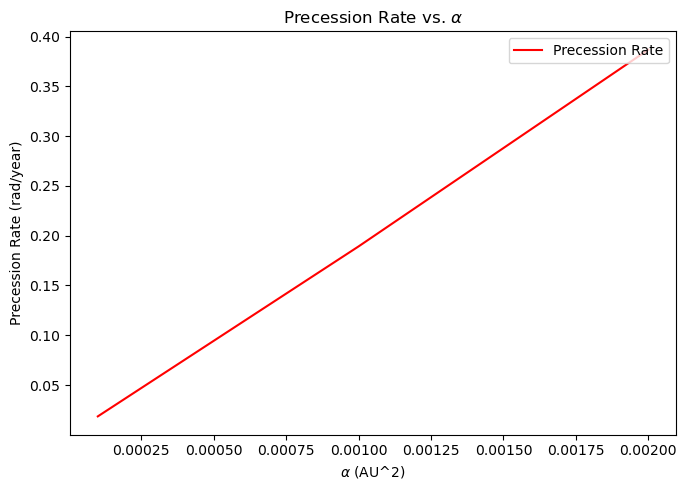

alpha = 0.0001 : Precession rate = 0.018563 rad/year
alpha = 0.0010 : Precession rate = 0.189246 rad/year
alpha = 0.0020 : Precession rate = 0.386813 rad/year
Precession rate at alpha=1.1e-8 is ~ 43.99075818369716 arcsec/century


In [265]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def radial_velocity(x, y, vx, vy):
    """Compute the radial velocity: v_r = (r . v)/|r|."""
    r = np.sqrt(x**2 + y**2)
    return (x * vx + y * vy) / r if r > 1e-15 else 0.0

def analyze_file(filename):
    """
    Loads the simulation data from filename.
    Detects aphelion times and angles via radial velocity sign changes.
    Returns time array, x, y, aphelion_times, aphelion_angles, and the 
    linear regression parameters (slope and intercept) for the aphelion angle vs. time.
    """
    data = np.loadtxt(filename)
    t  = data[:, 0]
    x  = data[:, 1]
    y  = data[:, 2]
    vx = data[:, 3]
    vy = data[:, 4]

    # Compute radial velocities for all time steps
    vr = np.array([radial_velocity(x[i], y[i], vx[i], vy[i]) for i in range(len(t))])
    
    # Detect aphelion points using the sign change of radial velocity:
    # Aphelion occurs when vr changes from positive to negative.
    aphelion_times = []
    aphelion_angles = []
    looking_for_aphelion = False  # start by waiting for a perihelion (vr from negative to positive)
    
    for i in range(1, len(t)):
        if looking_for_aphelion:
            if vr[i-1] > 0 and vr[i] <= 0:
                aphelion_times.append(t[i])
                aphelion_angles.append(np.arctan2(y[i], x[i]))
                looking_for_aphelion = False  # switch to looking for perihelion next
        else:
            if vr[i-1] < 0 and vr[i] >= 0:
                looking_for_aphelion = True  # now, next positive-to-negative will be an aphelion

    aphelion_times = np.array(aphelion_times)
    aphelion_angles = np.unwrap(np.array(aphelion_angles))  # Unwrap angles to avoid 2pi jumps

    # Linear regression to find precession rate (slope in rad/year)
    slope, intercept, r_value, p_value, std_err = linregress(aphelion_times, aphelion_angles)
    
    return t, x, y, aphelion_times, aphelion_angles, slope, intercept

# List of alpha values to test
alpha_list = [0.0001, 0.001, 0.002]
# Generate filenames using fixed 4-decimal formatting
filenames = ["mercury_gr_0.000100.txt", "mercury_gr_0.001000.txt", "mercury_gr_0.002000.txt"]

# Prepare lists to store precession rates
precession_rates = []

# Create a figure with side-by-side subplots for aphelion angle vs. time
fig_angles, axs = plt.subplots(1, len(alpha_list), figsize=(15, 5), sharey=True)
if len(alpha_list) == 1:
    axs = [axs]  # Ensure axs is iterable even if one alpha

# Loop over each alpha and corresponding file
for i, (alpha, fname) in enumerate(zip(alpha_list, filenames)):
    t, x, y, aph_times, aph_angles, slope, intercept = analyze_file(fname)
    precession_rates.append(slope)
    
    # Plot the aphelion angle vs. time with linear fit in its subplot
    axs[i].plot(aph_times, aph_angles, 'o')
    axs[i].plot(aph_times, slope * aph_times + intercept, 'r--',
                label=f"Linear Fit (slope = {slope:.4f} rad/yr)")
    axs[i].set_xlabel("Time (yrs)")
    axs[i].set_title(r'$\theta_p $ vs. Time ($\alpha$' + f" = {alpha:.4f})")
    axs[i].legend(loc="upper left")

# Set shared y-label
fig_angles.supylabel(r'$\theta_p$')

fig_angles.tight_layout()

# Plot precession rate vs. alpha
fig_rate, ax_rate = plt.subplots(figsize=(7,5))
ax_rate.plot(alpha_list, precession_rates, 'r-', label="Precession Rate")
ax_rate.set_xlabel(r"$\alpha$ (AU^2)")
ax_rate.set_ylabel("Precession Rate (rad/year)")
ax_rate.set_title(r"Precession Rate vs. $\alpha$")
ax_rate.legend(loc="upper right")
fig_rate.tight_layout()

plt.show()

# Print precession rates for each alpha
for alpha, rate in zip(alpha_list, precession_rates):
    print(f"alpha = {alpha:.4f} : Precession rate = {rate:.6f} rad/year")


# Convert precession rates to degrees/year
precession_rates_deg = np.array(precession_rates) * (180 / np.pi)

# Fit a linear model for precession rate vs. alpha
slope_deg_per_alpha, intercept, _, _, _ = linregress(alpha_list, precession_rates_deg)

# Extrapolate precession rate at alpha = 1.1e-8
dotTheta_deg_per_year = slope_deg_per_alpha * 1.1e-8
dotTheta_arcsec_per_century = dotTheta_deg_per_year * 3600 * 100

print("Precession rate at alpha=1.1e-8 is ~", dotTheta_arcsec_per_century, "arcsec/century")


In [299]:
import numpy as np
import scipy as sp

alpha = [0.0001, 0.001, 0.002]
files = ["mercury_gr_0.000100.txt", "mercury_gr_0.001000.txt", "mercury_gr_0.002000.txt"]

rates = []
for a, f in zip(alpha, files):
    _, _, _, times, angles, slope, _ = analyze_file(f)
    rates.append(slope)

ratesDeg = np.array(rates) * (180 / np.pi) #Converts to degrees per year
slopeDeg, intercept, _, _, _ = sp.stats.linregress(alpha, ratesDeg)

degYear = slopeDeg * 1.1e-8 #Using our alpha value
arcsec = degYear * 3600 * 100 #converts back to arcseconds/century

print(f"Precession rate at α=1.1e-8 AU²: {arcsec:.2f}")


Precession rate at α=1.1e-8 AU²: 43.99


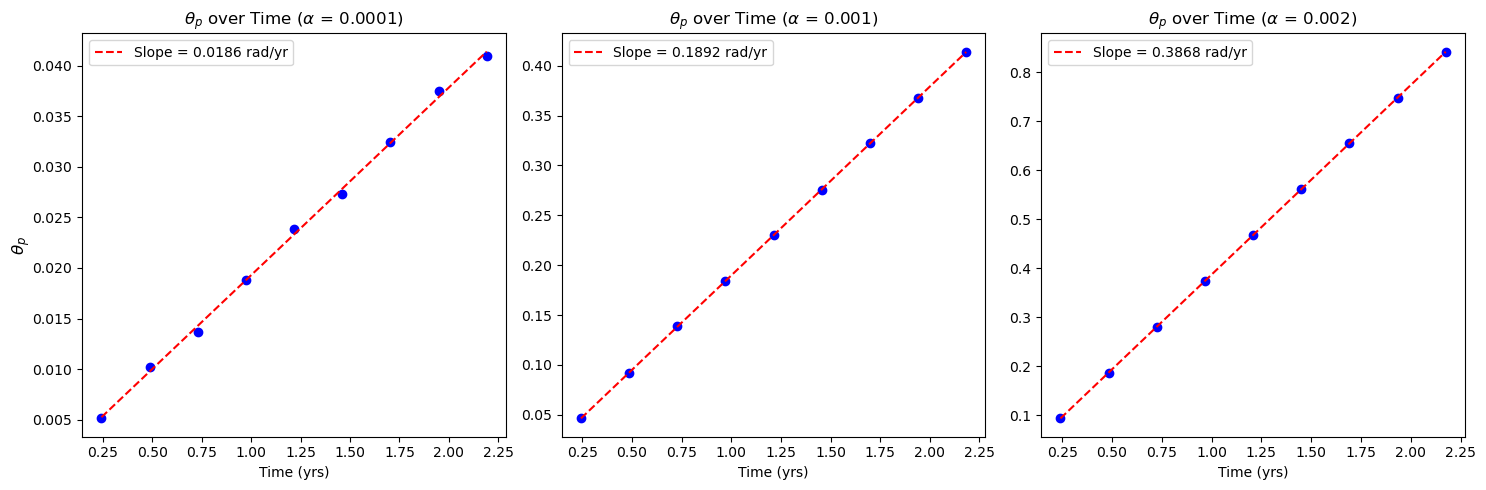

In [313]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import math

def radialVelocity(x, y, vx, vy):
    r = math.pow(math.pow(x, 2) + math.pow(y, 2), 0.5)
    if r > 1e-15:
        return (x * vx + y * vy) / r
    return 0.0

def processFile(filename):
    data = np.loadtxt(filename)
    t = data[:, 0]
    x = data[:, 1]
    y = data[:, 2]
    vx = data[:, 3]
    vy = data[:, 4]

    vr = [radialVelocity(x[i], y[i], vx[i], vy[i]) for i in range(len(t))]

    aphelionTimes = []
    aphelionAngles = []
    lookingForAphelion = False

    for i in range(1, len(t)):
        if lookingForAphelion and vr[i-1] > 0 >= vr[i]:
            aphelionTimes.append(t[i])
            aphelionAngles.append(math.atan2(y[i], x[i]))
            lookingForAphelion = False
        elif not lookingForAphelion and vr[i-1] < 0 <= vr[i]:
            lookingForAphelion = True

    slope, intercept, *_ = linregress(aphelionTimes, aphelionAngles)

    return aphelionTimes, aphelionAngles, slope, intercept

alphas = [0.0001, 0.001, 0.002]
files = ["mercury_gr_0.000100.txt", "mercury_gr_0.001000.txt", "mercury_gr_0.002000.txt"]

fig, axes = plt.subplots(1, len(alphas), figsize=(15, 5))

for i in range(len(alphas)):
    times, angles, slope, intercept = processFile(files[i])

    axes[i].plot(times, angles, 'o', color="blue")
    axes[i].plot(times, [slope * t + intercept for t in times], 'r--', label=f"Slope = {slope:.4f} rad/yr")
    axes[i].set_xlabel("Time (yrs)")
    axes[i].set_title(r"$\theta_p$ over Time ($\alpha$" + f" = {alphas[i]})")
    axes[i].legend(loc="upper left")

fig.supylabel(r"$\theta_p$")
fig.tight_layout()

plt.show()
